<a href="https://colab.research.google.com/github/AnalyticandProgramming/Educational-Data-Analysis-System/blob/main/Educational_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# الاتصال بـ Google Sheets
creds, _ = default()
gc = gspread.authorize(creds)

# فتح الملف (تأكد أن الاسم هو نفسه في Google Sheets)
wb = gc.open('بيانات المدرسة')
sheet = wb.sheet1

# قراءة البيانات وتحويلها لـ Pandas DataFrame
data = sheet.get_all_values()
df = pd.DataFrame(data[1:], columns=data[0])

# --- الجزء الديناميكي المحترف ---
num_records = len(df)
print(f"✅ تم الاتصال بنجاح! تم استيراد {num_records} سجل تعليمي.")

✅ تم الاتصال بنجاح! تم استيراد 600 سجل تعليمي.


In [ ]:
# تحويل الدرجات والحضور لأرقام
df['الدرجة'] = pd.to_numeric(df['الدرجة'])
df['نسبة الحضور'] = df['نسبة الحضور'].str.replace('%', '').astype(float)

# عرض أول 5 أسطر للتأكد
print("نموذج من البيانات المعالجة:")
print(df.head())

نموذج من البيانات المعالجة:
  اسم الطالب    الصف المادة  الدرجة  نسبة الحضور تاريخ الاختبار  \
0      طالب1  الصف أ  تاريخ      72         76.0      10-3-2025   
1      طالب2  الصف أ  تاريخ      75         80.0      10-3-2025   
2      طالب3  الصف أ  تاريخ      85         80.0      10-3-2025   
3      طالب4  الصف أ  تاريخ      84         89.0      10-3-2025   
4      طالب5  الصف أ  تاريخ      76         76.0      10-3-2025   

       تقييم المعلم      
0  مستوى جيد ومستقر      
1  مستوى جيد ومستقر      
2  مستوى جيد ومستقر      
3  مستوى جيد ومستقر      
4  مستوى جيد ومستقر      


In [ ]:
correlation = df['نسبة الحضور'].corr(df['الدرجة'])
print(f"📊 معامل ارتباط بيرسون هو: {correlation:.2f}")

# تعليق للموقع:
if correlation > 0.7:
    print("النتيجة: يوجد ارتباط طردي قوي جداً بين الالتزام بالحضور والتحصيل الدراسي.")

📊 معامل ارتباط بيرسون هو: 0.88
النتيجة: يوجد ارتباط طردي قوي جداً بين الالتزام بالحضور والتحصيل الدراسي.


In [ ]:
!pip install arabic-reshaper
!pip install python-bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 6.0 MB/s eta 0:00:00


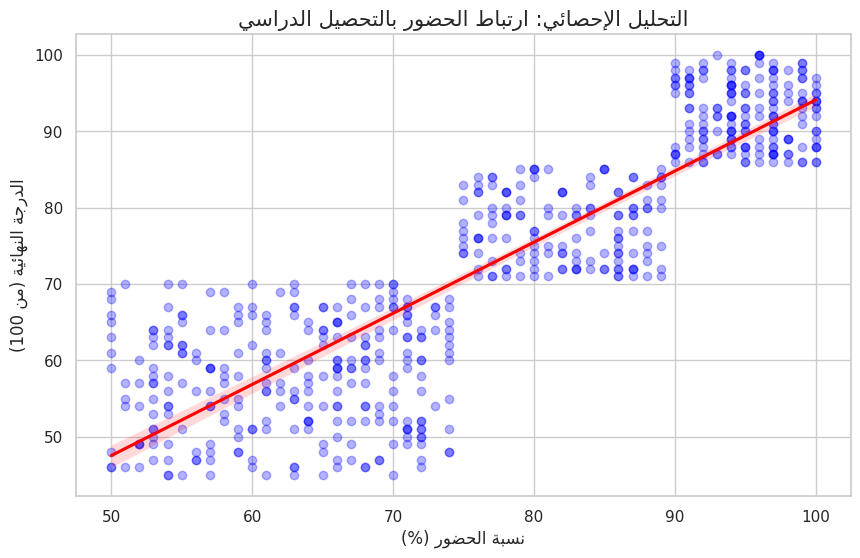

In [ ]:
import arabic_reshaper
from bidi.algorithm import get_display
import seaborn as sns
import matplotlib.pyplot as plt

# دالة بسيطة لتحويل النص العربي ليظهر بشكل صحيح
def arabic_text(text):
    reshaped_text = arabic_reshaper.reshape(text)
    return get_display(reshaped_text)

# 1. إعداد الشكل
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. رسم المخطط (باستخدام البيانات الحقيقية من df)
sns.regplot(x='نسبة الحضور', y='الدرجة', data=df,
            scatter_kws={'alpha':0.3, 'color':'blue'},
            line_kws={'color':'red'})

# 3. إضافة العناوين المعالجة عربياً
plt.title(arabic_text('التحليل الإحصائي: ارتباط الحضور بالتحصيل الدراسي'), fontsize=15)
plt.xlabel(arabic_text('نسبة الحضور (%)'), fontsize=12)
plt.ylabel(arabic_text('الدرجة النهائية (من 100)'), fontsize=12)

# 4. حفظ الصورة
plt.savefig('correlation_analysis_ar.png', dpi=300, bbox_inches='tight')
plt.show()
